# Include magnetism, spin-orbit coupling and superconductivity
These building blocks compose freely on the same Hamiltonian: `add_exchange`/`add_zeeman` for
magnetism, `add_soc`/`add_rashba` for spin-orbit coupling, and `add_swave`/`add_pairing` for
superconductivity. This is the recipe behind artificial topological superconductors: a Zeeman
field plus Rashba SOC plus s-wave pairing on a simple chain opens a topological gap hosting
Majorana end modes.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import islands

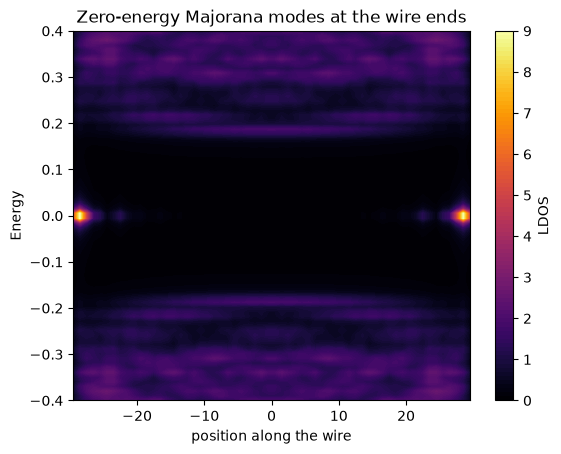

In [2]:
g = geometry.chain()
g = g.get_supercell(60)
g.dimensionality = 0 # make it a finite wire

h = g.get_hamiltonian()
h.add_onsite(2.0)          # shift the chemical potential
h.add_rashba(.5)           # Rashba spin-orbit coupling
h.add_exchange([0.,0.,.5]) # Zeeman/exchange field
h.add_swave(0.2)           # s-wave superconducting pairing

energies = np.linspace(-0.4,0.4,80)
dmap = []
for e in energies:
    x,y,d = h.get_ldos(delta=1e-2,e=e) # local DOS at each site, for this energy
    dmap.append(d)
dmap = np.array(dmap)

plt.contourf(x,energies,dmap,levels=100,cmap="inferno")
plt.colorbar(label="LDOS")
plt.xlabel("position along the wire") ; plt.ylabel("Energy")
plt.title("Zero-energy Majorana modes at the wire ends")
plt.show()